# Market Share Fact Tables

This section documents the initial data preprocessing and market share calculation workflow before the data is transformed into a star schema structure.

## Data Overview
We start by loading vehicle registration data from a CSV file and perform essential data cleaning operations:

- **Geographic Data Cleaning**: Fill missing values in geographic columns with "N/A"
- **Body Type Standardization**: Map various body type variations to a consistent set of categories
- **Market Share Calculation**: Calculate monthly market share percentages for each OEM at both country and district levels

## Market Share Methodology
The market share calculation follows this approach:

1. **Total Vehicle Counts**: Aggregate total vehicles by time period, geographic level, and vehicle characteristics
2. **OEM-Specific Counts**: Calculate vehicles per OEM within each market segment
3. **Market Share Computation**: Divide OEM vehicles by total market vehicles for each segment

## Output Tables
This process generates two primary fact tables:

- **Country Level**: `fact_market_share_country` - Market share aggregated by country
- **District Level**: `fact_market_share_district` - Market share at detailed geographic level

Both tables include comprehensive metadata descriptions and are saved as Parquet files for efficient storage and querying.

In [111]:
import pandas as pd

In [112]:
df = pd.read_csv("../data/data.csv")

In [113]:
df.head()

,oem,year_report,month_report,level_0_country,level_1_region_name,level_2_district_postcode,level_2_district_town_name,level_3_postcode_sector_hyperlocal,model_class,model_class_specific,body_type,fuel_type,doors,Energy_Source,vehicle_count
0,ASTON MARTIN,2024,4,Northern Ireland,Magherafelt,BT45,NaN,BT458,DB11,V12,SPORTCOUPE,PETROL,2,NORMAL,1
1,ASTON MARTIN,2024,1,England,Salford,M28,Walkden,M282,DB12,V8,SPORTCOUPE,PETROL,2,NORMAL,1
2,ASTON MARTIN,2024,3,England,Cambridgeshire,CB7,Soham,CB75,DB12,V8,SPORTCOUPE,PETROL,2,NORMAL,1
3,ASTON MARTIN,2024,4,England,Leicester,LE1,Leicester,LE17,DB12,V8,SPORTCOUPE,PETROL,2,NORMAL,1
4,ASTON MARTIN,2024,4,England,Leeds,LS1,NaN,LS14,DB12,V8,SPORTCOUPE,PETROL,2,NORMAL,1


In [114]:
# Fill NA values with "N/A" for specific geographic columns
geo_columns = ['level_0_country','level_1_region_name', 'level_2_district_postcode',
       'level_2_district_town_name', 'level_3_postcode_sector_hyperlocal']

df[geo_columns] = df[geo_columns].fillna("N/A")

# Map body types to a standardized set
mapping_body_types = {'SPORTCOUPE':'SPORTSCOUPE', 
                      'CABRIO':'CABRIO', 
                'SUV':'SUV', 
                'HATCHBACK':'ESTATE', 
                'COUPE':'COUPE', 
                'SEDAN':'SEDAN',
                'ESTATE':'ESTATE', 
                'SUC':'SUV', 
                'CAPRIO':'CABRIO', 
                'MPV':'MPV'}

df["body_type"] = df["body_type"].map(mapping_body_types)

In [115]:
df_org = df.copy()

In [116]:
levels = (("country", ['level_0_country']), 
         ("district", ['level_0_country',
                     'level_1_region_name', 'level_2_district_postcode',
                     'level_2_district_town_name']))


time_cols = ['year_report', 'month_report']
car_cols = ['body_type', 'fuel_type']

dfs_market_share = {}

for level, level_cols in levels:

       print(f"Processing market share for level: {level}")

       total_count_id_district_cols = time_cols + level_cols + car_cols

       df['total_vehicle_count_id'] = df[total_count_id_district_cols].apply(lambda x: '_'.join(x.astype(str)), axis=1)

       market_share_id_cols = ['oem'] + time_cols + level_cols + car_cols 

       df['market_share_id'] = df[market_share_id_cols].apply(lambda x: '_'.join(x.astype(str)), axis=1)

       # calculate monthly market share per OEM
       df[f"total_vehicles_{level}"] = df.groupby(total_count_id_district_cols)["vehicle_count"].transform("sum")
       df[f"total_vehicles_{level}_oem"] = df.groupby(market_share_id_cols)["vehicle_count"].transform("sum")

       df_market_share = df[['total_vehicle_count_id','market_share_id'] + market_share_id_cols + [f'total_vehicles_{level}', f'total_vehicles_{level}_oem']].copy()

       # Create monthly market share per OEM
       df_market_share["year_month"] = pd.to_datetime(df_market_share["year_report"].astype(str) + "-" + df_market_share['month_report'].astype(str), format="%Y-%m")

       df_market_share[f'market_share_{level}'] = df_market_share[f'total_vehicles_{level}_oem'] / df_market_share[f'total_vehicles_{level}']

       dfs_market_share[level] = df_market_share


Processing market share for level: country
Processing market share for level: district


In [117]:
fact_market_share_country = dfs_market_share['country'].copy()
fact_market_share_district = dfs_market_share['district'].copy()

fact_market_share_country_description = {'total_vehicle_count_id': "Uniquely identifies the total vehicle count for a specific year, month, body type, fuel type, and geographic level",
'market_share_id': "Uniquely identifies the market share for a specific OEM, year, month, body type, fuel type, and geographic level",
'oem': "The original equipment manufacturer (OEM) of the vehicle",
'year_report': "The year in which the vehicles were registered",
'month_report': "The month in which the vehicles were registered",
'level_0_country': "The country at the highest geographic level",
'body_type': "The body type of the vehicle (e.g., sedan, SUV)",
'fuel_type': "The fuel type of the vehicle (e.g., petrol, diesel)",
'total_vehicles_country': "The total number of vehicles in the country",
'total_vehicles_country_oem': "The total number of vehicles for the OEM in the country",
'year_month': "The year and month for the data point",
'market_share_country': "The market share of the OEM in the country for the specified market_share_id"}

fact_market_share_district_description = {
    'total_vehicle_count_id': "Uniquely identifies the total vehicle count for a specific year, month, body type, fuel type, and geographic level district",
    'market_share_id': "Uniquely identifies the market share for a specific OEM, year, month, body type, fuel_type, and geographic level district",
    'oem': "The original equipment manufacturer (OEM) of the vehicle",
    'year_report': "The year in which the vehicles were registered",
    'month_report': "The month in which the vehicles were registered",
    'level_0_country': "The country at the highest geographic level",
    'level_1_region_name': "The name of the region at the first sub-national level",
    'level_2_district_postcode': "The postcode of the district",
    'level_2_district_town_name': "The name of the town in the district",
    'body_type': "The body type of the vehicle (e.g., sedan, SUV)",
    'fuel_type': "The fuel type of the vehicle (e.g., petrol, diesel)",
    'total_vehicles_district': "The total number of vehicles in the district",
    'total_vehicles_district_oem': "The total number of vehicles for the OEM in the district",
    'year_month': "The year and month for the data point",
    'market_share_district': "The market share of the OEM in the district for the specified market_share_id"}



# Store files as parquet 
fact_market_share_country.to_parquet("../data/fact_market_share_country.parquet", index=False)
fact_market_share_district.to_parquet("../data/fact_market_share_district.parquet", index=False)

# Store Metadata als JSON
import json
metadata = {
    'fact_market_share_country': fact_market_share_country_description,
    'fact_market_share_district': fact_market_share_district_description
}
with open("../data/metadata.json", "w") as f:
    json.dump(metadata, f)

## Store Registered Vehicles Data as Main Fact Table

In [118]:
fact_registered_vehicles_description = {
    'vehicle_count_id':"Uniquely identifies the vehicle count for a specific year, month, body type, fuel type, and geographic level", 
    'oem': "The original equipment manufacturer (OEM) of the vehicle",
    'year_report': "The year in which the vehicles were registered",
    'month_report': "The month in which the vehicles were registered",
    'level_0_country': "The country at the highest geographic level",
    'level_1_region_name': "The name of the region at the first sub-national level",
    'level_2_district_postcode': "The postcode of the district",
    'level_2_district_town_name': "The name of the town in the district",
    'model_class': "The class of the vehicle model",
    'model_class_specific': "The specific variant of the vehicle model",
    'body_type': "The body type of the vehicle (e.g., sedan, SUV)",
    'fuel_type': "The fuel type of the vehicle (e.g., petrol, diesel)",
    'doors': "The number of doors on the vehicle",
    'Energy_Source': "The energy source of the vehicle (e.g., electric, hybrid)",
    'vehicle_count': "The count of vehicles registered for the specified parameters"}

In [119]:
selected_columns = ['oem', 'year_report', 'month_report', 'level_0_country',
       'level_1_region_name', 'level_2_district_postcode',
       'level_2_district_town_name', 
       'model_class', 'model_class_specific', 'body_type', 'fuel_type',
       'doors', 'Energy_Source', 'vehicle_count']

id_columns = ['oem', 'year_report', 'month_report', 'level_0_country',
       'level_1_region_name', 'level_2_district_postcode',
       'level_2_district_town_name', 
       'model_class', 'model_class_specific', 'body_type', 'fuel_type',
       'doors', 'Energy_Source', 'vehicle_count']

# create ID for vehicle count
df_org['vehicle_count_id'] = df_org[selected_columns].apply(lambda x: '_'.join(x.astype(str)), axis=1)

df_org = df_org[['vehicle_count_id'] + selected_columns].copy()

df_org.head()

,vehicle_count_id,oem,year_report,month_report,level_0_country,level_1_region_name,level_2_district_postcode,level_2_district_town_name,model_class,model_class_specific,body_type,fuel_type,doors,Energy_Source,vehicle_count
0,ASTON MARTIN_2024_4_Northern Ireland_Magherafe...,ASTON MARTIN,2024,4,Northern Ireland,Magherafelt,BT45,N/A,DB11,V12,SPORTSCOUPE,PETROL,2,NORMAL,1
1,ASTON MARTIN_2024_1_England_Salford_M28_Walkde...,ASTON MARTIN,2024,1,England,Salford,M28,Walkden,DB12,V8,SPORTSCOUPE,PETROL,2,NORMAL,1
2,ASTON MARTIN_2024_3_England_Cambridgeshire_CB7...,ASTON MARTIN,2024,3,England,Cambridgeshire,CB7,Soham,DB12,V8,SPORTSCOUPE,PETROL,2,NORMAL,1
3,ASTON MARTIN_2024_4_England_Leicester_LE1_Leic...,ASTON MARTIN,2024,4,England,Leicester,LE1,Leicester,DB12,V8,SPORTSCOUPE,PETROL,2,NORMAL,1
4,ASTON MARTIN_2024_4_England_Leeds_LS1_N/A_DB12...,ASTON MARTIN,2024,4,England,Leeds,LS1,N/A,DB12,V8,SPORTSCOUPE,PETROL,2,NORMAL,1


In [120]:
# Group by vehicle_count_id and sum duplicates, then add all columns back
_df = df_org[['vehicle_count_id', 'vehicle_count']].groupby('vehicle_count_id').sum().reset_index()
_df = _df.merge(df_org.drop(columns=['vehicle_count']).drop_duplicates(), on='vehicle_count_id', how='left')

In [121]:
assert _df.drop_duplicates(subset='vehicle_count_id').shape[0] == _df.shape[0], "Duplicate vehicle_count_id found"

In [122]:
_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318795 entries, 0 to 318794
Data columns (total 15 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   vehicle_count_id            318795 non-null  object
 1   vehicle_count               318795 non-null  int64 
 2   oem                         318795 non-null  object
 3   year_report                 318795 non-null  int64 
 4   month_report                318795 non-null  int64 
 5   level_0_country             318795 non-null  object
 6   level_1_region_name         318795 non-null  object
 7   level_2_district_postcode   318795 non-null  object
 8   level_2_district_town_name  318795 non-null  object
 9   model_class                 318795 non-null  object
 10  model_class_specific        318795 non-null  object
 11  body_type                   318795 non-null  object
 12  fuel_type                   318795 non-null  object
 13  doors                       3

In [123]:
_df.to_parquet("../data/fact_registered_vehicles.parquet", index=False)

# Data Analytics

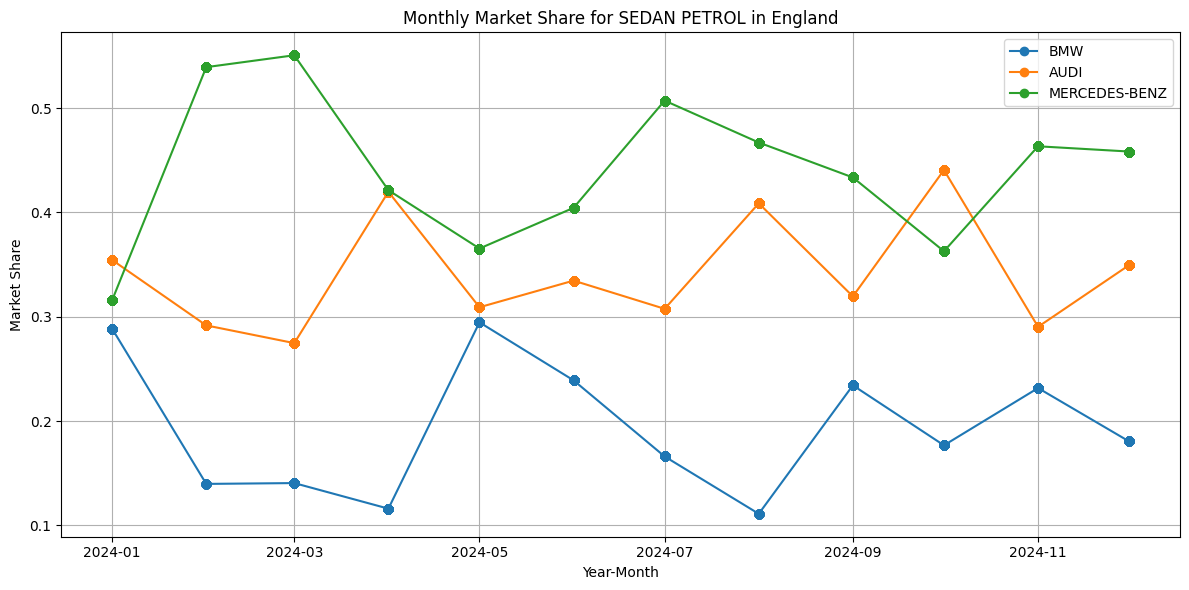

In [15]:
import matplotlib.pyplot as plt

# Filter for BMW, AUDI, MERCEDES-BENZ, SEDAN, PETROL in England
oems = ['BMW', 'AUDI', 'MERCEDES-BENZ']
df_plot_multi = fact_market_share_country[
    (fact_market_share_country['oem'].isin(oems)) &
    (fact_market_share_country['body_type'] == 'SEDAN') &
    (fact_market_share_country['fuel_type'] == 'PETROL') &
    (fact_market_share_country['level_0_country'] == 'England')
]

# Sort by year_month
df_plot_multi = df_plot_multi.sort_values('year_month')

plt.figure(figsize=(12, 6))
for oem in oems:
    df_oem = df_plot_multi[df_plot_multi['oem'] == oem]
    plt.plot(df_oem['year_month'], df_oem['market_share_country'], marker='o', label=oem)

plt.title('Monthly Market Share for SEDAN PETROL in England')
plt.xlabel('Year-Month')
plt.ylabel('Market Share')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
fact_market_share_district.columns

Index(['total_vehicle_count_id', 'market_share_id', 'oem', 'year_report',
       'month_report', 'level_0_country', 'level_1_region_name',
       'level_2_district_postcode', 'level_2_district_town_name', 'body_type',
       'fuel_type', 'total_vehicles_district', 'total_vehicles_district_oem',
       'year_month', 'market_share_district'],
      dtype='object')

# Star Schema Creation

This section transforms the preprocessed market share data into a dimensional star schema structure for optimized analytical querying. The ETL process creates:

## Dimension Tables
- **DimTime**: Time-based attributes with quarterly aggregations
- **DimOEM**: Original Equipment Manufacturer details with categorization
- **DimVehicle**: Vehicle type combinations (body type + fuel type)
- **DimGeographyCountry**: Country-level geographic dimensions
- **DimGeographyDistrict**: Detailed district-level geographic dimensions

## Fact Tables
- **FactMarketShareCountry**: Aggregated market share metrics at country level
- **FactMarketShareDistrict**: Detailed market share metrics at district level

The star schema design enables efficient joins and analytical queries while maintaining data integrity through surrogate keys. This structure supports complex business intelligence queries and provides better performance compared to the original normalized fact tables.

In [ ]:
# Run the star schema ETL process
import sys
import os

# Add the project root to the path
project_root = os.path.dirname(os.getcwd())
sys.path.append(project_root)

# Import and run the ETL
from scripts.create_star_schema import VehicleMarketStarSchemaETL

# Initialize ETL processor
data_dir = "../data"
output_dir = "../data/star_schema"
etl = VehicleMarketStarSchemaETL(data_dir=data_dir, output_dir=output_dir)

# Run the ETL process
print("Running Star Schema ETL...")
etl.run_etl()

In [18]:
# Examine the created star schema tables
import pandas as pd
import os

star_schema_dir = "../data/star_schema"

# Load and examine dimension tables
print("=== DIMENSION TABLES ===\n")

# DimTime
dim_time = pd.read_parquet(os.path.join(star_schema_dir, "DimTime.parquet"))
print("DimTime (first 5 rows):")
print(dim_time.head())
print(f"Shape: {dim_time.shape}\n")

# DimOEM
dim_oem = pd.read_parquet(os.path.join(star_schema_dir, "DimOEM.parquet"))
print("DimOEM (first 10 rows):")
print(dim_oem.head(10))
print(f"Shape: {dim_oem.shape}\n")

# DimVehicle
dim_vehicle = pd.read_parquet(os.path.join(star_schema_dir, "DimVehicle.parquet"))
print("DimVehicle:")
print(dim_vehicle)
print(f"Shape: {dim_vehicle.shape}\n")

# DimGeographyCountry
dim_geo_country = pd.read_parquet(os.path.join(star_schema_dir, "DimGeographyCountry.parquet"))
print("DimGeographyCountry:")
print(dim_geo_country)
print(f"Shape: {dim_geo_country.shape}\n")

# DimGeographyDistrict (sample)
dim_geo_district = pd.read_parquet(os.path.join(star_schema_dir, "DimGeographyDistrict.parquet"))
print("DimGeographyDistrict (first 10 rows):")
print(dim_geo_district.head(10))
print(f"Shape: {dim_geo_district.shape}\n")

=== DIMENSION TABLES ===

DimTime (first 5 rows):
   time_key  year_report  month_report year_month  quarter year_quarter
0    202404         2024             4 2024-04-01        2      2024-Q2
1    202401         2024             1 2024-01-01        1      2024-Q1
2    202403         2024             3 2024-03-01        1      2024-Q1
3    202409         2024             9 2024-09-01        3      2024-Q3
4    202411         2024            11 2024-11-01        4      2024-Q4
Shape: (12, 6)

DimOEM (first 10 rows):
   oem_key       oem_name oem_category country_origin
0        1   ASTON MARTIN       Luxury             UK
1        2           AUDI       Luxury        Germany
2        3        BENTLEY       Luxury             UK
3        4            BMW       Luxury        Germany
4        5        FERRARI       Luxury          Italy
5        6         JAGUAR       Luxury             UK
6        7          LEXUS      Premium          Japan
7        8       MASERATI       Luxury        

In [20]:
# Examine fact tables and perform sample analytical queries
print("=== FACT TABLES ===\n")

# Load fact tables
fact_country = pd.read_parquet(os.path.join(star_schema_dir, "FactMarketShareCountry.parquet"))
fact_district = pd.read_parquet(os.path.join(star_schema_dir, "FactMarketShareDistrict.parquet"))

print("FactMarketShareCountry (sample):")
print(fact_country.head())
print(f"Shape: {fact_country.shape}\n")

print("FactMarketShareDistrict (sample):")
print(fact_district.head())
print(f"Shape: {fact_district.shape}\n")

print("=== SAMPLE ANALYTICAL QUERIES ===\n")

# Query 1: Top 5 OEMs by total vehicles in country-level data
print("1. Top 5 OEMs by Total Vehicles (Country Level):")
oem_performance = fact_country.groupby('oem_key').agg({
    'total_vehicles_country_oem': 'sum',
    'market_share_country': 'mean'
}).reset_index()

# Join with OEM dimension for names
oem_performance = oem_performance.merge(dim_oem[['oem_key', 'oem_name', 'oem_category']], on='oem_key')
oem_performance = oem_performance.sort_values('total_vehicles_country_oem', ascending=False).head()

for _, row in oem_performance.iterrows():
    print(f"  {row['oem_name']} ({row['oem_category']}): {row['total_vehicles_country_oem']:,} vehicles, "
          f"{row['market_share_country']:.4f} avg market share")

print()

# Query 2: Vehicle type performance
print("2. Vehicle Type Performance:")
vehicle_performance = fact_country.groupby('vehicle_key').agg({
    'total_vehicles_country_oem': 'sum',
    'market_share_country': 'mean'
}).reset_index()

vehicle_performance = vehicle_performance.merge(dim_vehicle, on='vehicle_key')
vehicle_performance = vehicle_performance.sort_values('total_vehicles_country_oem', ascending=False)

for _, row in vehicle_performance.iterrows():
    print(f"  {row['vehicle_desc']}: {row['total_vehicles_country_oem']:,} vehicles, "
          f"{row['market_share_country']:.4f} avg market share")

print()

# Query 3: Geographic performance (country level)
print("3. Geographic Performance by Country:")
geo_performance = fact_country.groupby('geography_country_key').agg({
    'total_vehicles_country': 'mean',
    'market_share_country': 'mean'
}).reset_index()

geo_performance = geo_performance.merge(dim_geo_country, on='geography_country_key')
geo_performance = geo_performance.sort_values('total_vehicles_country', ascending=False)

for _, row in geo_performance.iterrows():
    print(f"  {row['country_name']} ({row['country_code']}): {row['total_vehicles_country']:,.0f} avg total vehicles")

print()

# Query 4: Time trend analysis (monthly aggregation)
print("4. Monthly Market Trends (Total Vehicles by Month):")
time_trends = fact_country.groupby('time_key').agg({
    'total_vehicles_country': 'mean'
}).reset_index()

time_trends = time_trends.merge(dim_time[['time_key', 'year_report', 'month_report']], on='time_key')
time_trends = time_trends.sort_values('time_key').head(10)

for _, row in time_trends.iterrows():
    year = int(row['year_report'])
    month = int(row['month_report'])
    vehicles = int(row['total_vehicles_country'])
    print(f"  {year}-{month:02d}: {vehicles:,} avg vehicles")

=== FACT TABLES ===

FactMarketShareCountry (sample):
   fact_country_key  time_key  oem_key  vehicle_key  geography_country_key  \
0                 1    202404        1            1                    5.0   
1                 2    202401        1            1                    1.0   
2                 3    202403        1            1                    1.0   
3                 4    202404        1            1                    1.0   
4                 5    202404        1            1                    1.0   

   total_vehicles_country  total_vehicles_country_oem  market_share_country  
0                    13.0                         1.0              0.076923  
1                   527.0                        66.0              0.125237  
2                   885.0                        79.0              0.089266  
3                   426.0                        27.0              0.063380  
4                   426.0                        27.0              0.063380  
Shape: (3

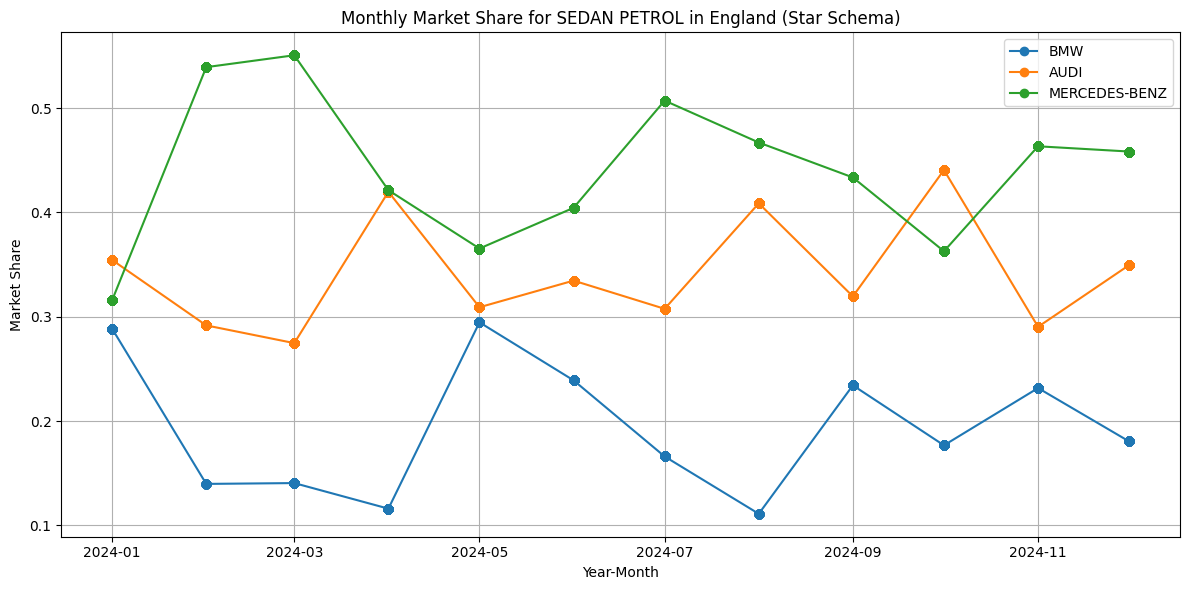

Total rows in star schema plot: 19049
Unique OEMs: ['BMW' 'AUDI' 'MERCEDES-BENZ']


In [21]:
# Replicate the analysis using the star schema with proper joins
# Filter for BMW, AUDI, MERCEDES-BENZ, SEDAN, PETROL in England using dimension joins

# Get the keys for filtering
oem_keys = dim_oem[dim_oem['oem_name'].isin(['BMW', 'AUDI', 'MERCEDES-BENZ'])]['oem_key'].tolist()
vehicle_key = dim_vehicle[(dim_vehicle['body_type'] == 'SEDAN') & (dim_vehicle['fuel_type'] == 'PETROL')]['vehicle_key'].iloc[0]
geography_key = dim_geo_country[dim_geo_country['country_name'] == 'England']['geography_country_key'].iloc[0]

# Filter the fact table using the keys
df_plot_star = fact_country[
    (fact_country['oem_key'].isin(oem_keys)) &
    (fact_country['vehicle_key'] == vehicle_key) &
    (fact_country['geography_country_key'] == geography_key)
]

# Join with dimension tables to get descriptive names
df_plot_star = df_plot_star.merge(dim_oem[['oem_key', 'oem_name']], on='oem_key')
df_plot_star = df_plot_star.merge(dim_time[['time_key', 'year_month']], on='time_key')

# Sort by year_month
df_plot_star = df_plot_star.sort_values('year_month')

# Create the plot
plt.figure(figsize=(12, 6))
for oem_name in ['BMW', 'AUDI', 'MERCEDES-BENZ']:
    df_oem = df_plot_star[df_plot_star['oem_name'] == oem_name]
    plt.plot(df_oem['year_month'], df_oem['market_share_country'], marker='o', label=oem_name)

plt.title('Monthly Market Share for SEDAN PETROL in England (Star Schema)')
plt.xlabel('Year-Month')
plt.ylabel('Market Share')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Total rows in star schema plot: {len(df_plot_star)}")
print(f"Unique OEMs: {df_plot_star['oem_name'].unique()}")

In [26]:
import numpy as np

# Convert both series to numpy arrays and round to 3 decimal places
star_values = np.round(df_plot_star['market_share_country'].values, 3)
multi_values = np.round(df_plot_multi['market_share_country'].values, 3)

# Check if arrays have the same length
print(f"Star schema length: {len(star_values)}")
print(f"Multi table length: {len(multi_values)}")

# Check if all values are equal with 3 decimal precision
arrays_equal = np.array_equal(star_values, multi_values)
print(f"Arrays are equal (3 decimal precision): {arrays_equal}")

# If not equal, show differences
if not arrays_equal:
    # Find positions where values differ
    diff_mask = star_values != multi_values
    if np.any(diff_mask):
        print(f"Number of differing positions: {np.sum(diff_mask)}")
        print("First 5 differences:")
        diff_indices = np.where(diff_mask)[0][:5]
        for idx in diff_indices:
            print(f"Position {idx}: Star={star_values[idx]}, Multi={multi_values[idx]}")

Star schema length: 19049
Multi table length: 19049
Arrays are equal (3 decimal precision): True


# SQLite Database

In [27]:
import sqlite3

# Connect to the SQLite database
conn = sqlite3.connect("../data/market_share.sqlite")

# Get a cursor object
cursor = conn.cursor()

# List all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

print("Tables in the database:")
for table in tables:
    print(f"  - {table[0]}")

# Close the connection
conn.close()

Tables in the database:
  - DimTime
  - DimOEM
  - DimVehicle
  - DimGeographyCountry
  - DimGeographyDistrict
  - FactMarketShareCountry
  - FactMarketShareDistrict


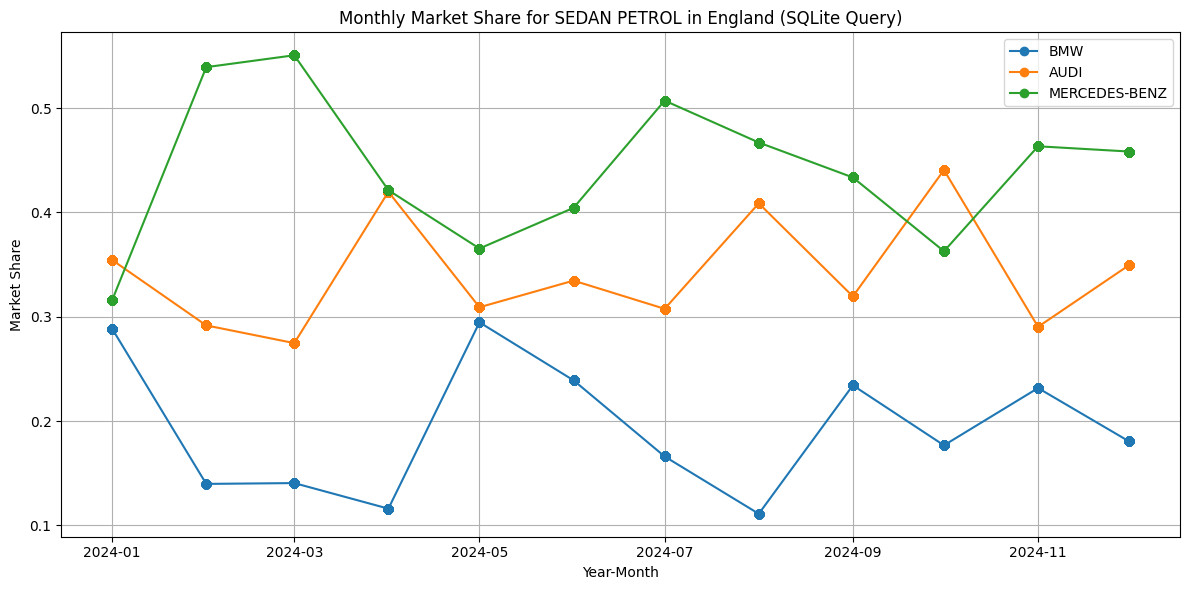

Total rows from SQLite query: 19049
Unique OEMs: ['AUDI' 'BMW' 'MERCEDES-BENZ']
Data shape: (19049, 3)


In [28]:
# Replicate the analysis using SQLite database with SQL queries
# Filter for BMW, AUDI, MERCEDES-BENZ, SEDAN, PETROL in England using SQL joins

# Connect to the SQLite database
conn = sqlite3.connect("../data/market_share.sqlite")

# SQL query to get the same data using joins
sql_query = """
SELECT 
    f.market_share_country,
    o.oem_name,
    t.year_month
FROM FactMarketShareCountry f
JOIN DimOEM o ON f.oem_key = o.oem_key
JOIN DimVehicle v ON f.vehicle_key = v.vehicle_key
JOIN DimGeographyCountry g ON f.geography_country_key = g.geography_country_key
JOIN DimTime t ON f.time_key = t.time_key
WHERE 
    o.oem_name IN ('BMW', 'AUDI', 'MERCEDES-BENZ')
    AND v.body_type = 'SEDAN'
    AND v.fuel_type = 'PETROL'
    AND g.country_name = 'England'
ORDER BY t.year_month, o.oem_name
"""

# Execute query and get results
df_plot_sql = pd.read_sql_query(sql_query, conn)

# Close the connection
conn.close()

# Convert year_month to datetime for plotting
df_plot_sql['year_month'] = pd.to_datetime(df_plot_sql['year_month'])

# Create the plot
plt.figure(figsize=(12, 6))
for oem_name in ['BMW', 'AUDI', 'MERCEDES-BENZ']:
    df_oem = df_plot_sql[df_plot_sql['oem_name'] == oem_name]
    plt.plot(df_oem['year_month'], df_oem['market_share_country'], marker='o', label=oem_name)

plt.title('Monthly Market Share for SEDAN PETROL in England (SQLite Query)')
plt.xlabel('Year-Month')
plt.ylabel('Market Share')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Total rows from SQLite query: {len(df_plot_sql)}")
print(f"Unique OEMs: {df_plot_sql['oem_name'].unique()}")
print(f"Data shape: {df_plot_sql.shape}")

In [33]:
# Connect to the SQLite database
conn = sqlite3.connect("../data/market_share.sqlite")

# SQL query to get the same data using joins
sql_query = """
SELECT oem_name, AVG(market_share_country) AS avg_market_share
FROM FactMarketShareCountry f
JOIN DimOEM o ON f.oem_key = o.oem_key
GROUP BY oem_name
ORDER BY avg_market_share DESC
"""

# Execute query and get results
df_plot_sql = pd.read_sql_query(sql_query, conn)

# Close the connection
conn.close()


df_plot_sql

,oem_name,avg_market_share
0,FERRARI,0.415611
1,POLESTAR,0.409484
2,BMW,0.388818
3,VOLVO,0.378844
4,MINI,0.356139
5,AUDI,0.309971
6,MERCEDES-BENZ,0.299693
7,LEXUS,0.233511
8,PORSCHE,0.197147
9,JAGUAR,0.178767


In [34]:
# Load fact tables
fact_country = pd.read_parquet(os.path.join(star_schema_dir, "FactMarketShareCountry.parquet"))
fact_district = pd.read_parquet(os.path.join(star_schema_dir, "FactMarketShareDistrict.parquet"))


In [37]:
fact_country.groupby('oem_key').agg({
    'total_vehicles_country_oem': 'sum',
    'market_share_country': 'mean'
}).reset_index().sort_values(by='market_share_country', ascending=False)


,oem_key,total_vehicles_country_oem,market_share_country
4,5,25681.0,0.415611
10,11,777603.0,0.409484
3,4,76875152.0,0.388818
12,13,64999077.0,0.378844
9,10,84940500.0,0.356139
1,2,134752115.0,0.309971
8,9,79949907.0,0.299693
6,7,6279881.0,0.233511
11,12,5779465.0,0.197147
5,6,4590145.0,0.178767


In [41]:
dim_OEM = pd.read_parquet(os.path.join(star_schema_dir, "DimOEM.parquet"))
dim_OEM

,oem_key,oem_name,oem_category,country_origin
0,1,ASTON MARTIN,Luxury,UK
1,2,AUDI,Luxury,Germany
2,3,BENTLEY,Luxury,UK
3,4,BMW,Luxury,Germany
4,5,FERRARI,Luxury,Italy
5,6,JAGUAR,Luxury,UK
6,7,LEXUS,Premium,Japan
7,8,MASERATI,Luxury,Italy
8,9,MERCEDES-BENZ,Luxury,Germany
9,10,MINI,Mass Market,Unknown


In [54]:
fact_country = pd.read_parquet("../data/fact_market_share_country.parquet")

In [64]:
fact_country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334124 entries, 0 to 334123
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   total_vehicle_count_id      334124 non-null  object        
 1   market_share_id             334124 non-null  object        
 2   oem                         334124 non-null  object        
 3   year_report                 334124 non-null  int64         
 4   month_report                334124 non-null  int64         
 5   level_0_country             333844 non-null  object        
 6   body_type                   334124 non-null  object        
 7   fuel_type                   334124 non-null  object        
 8   total_vehicles_country      333844 non-null  float64       
 9   total_vehicles_country_oem  333844 non-null  float64       
 10  year_month                  334124 non-null  datetime64[ns]
 11  market_share_country        333844 non-

In [65]:
fact_country.head()

,total_vehicle_count_id,market_share_id,oem,year_report,month_report,level_0_country,body_type,fuel_type,total_vehicles_country,total_vehicles_country_oem,year_month,market_share_country
0,2024_4_Northern Ireland_SPORTSCOUPE_PETROL,ASTON MARTIN_2024_4_Northern Ireland_SPORTSCOU...,ASTON MARTIN,2024,4,Northern Ireland,SPORTSCOUPE,PETROL,13.0,1.0,2024-04-01,0.076923
1,2024_1_England_SPORTSCOUPE_PETROL,ASTON MARTIN_2024_1_England_SPORTSCOUPE_PETROL,ASTON MARTIN,2024,1,England,SPORTSCOUPE,PETROL,527.0,66.0,2024-01-01,0.125237
2,2024_3_England_SPORTSCOUPE_PETROL,ASTON MARTIN_2024_3_England_SPORTSCOUPE_PETROL,ASTON MARTIN,2024,3,England,SPORTSCOUPE,PETROL,885.0,79.0,2024-03-01,0.089266
3,2024_4_England_SPORTSCOUPE_PETROL,ASTON MARTIN_2024_4_England_SPORTSCOUPE_PETROL,ASTON MARTIN,2024,4,England,SPORTSCOUPE,PETROL,426.0,27.0,2024-04-01,0.063380
4,2024_4_England_SPORTSCOUPE_PETROL,ASTON MARTIN_2024_4_England_SPORTSCOUPE_PETROL,ASTON MARTIN,2024,4,England,SPORTSCOUPE,PETROL,426.0,27.0,2024-04-01,0.063380


In [58]:
df.head()

,oem,year_report,month_report,level_0_country,level_1_region_name,level_2_district_postcode,level_2_district_town_name,level_3_postcode_sector_hyperlocal,model_class,model_class_specific,...,fuel_type,doors,Energy_Source,vehicle_count,total_vehicle_count_id,market_share_id,total_vehicles_country,total_vehicles_country_oem,total_vehicles_district,total_vehicles_district_oem
0,ASTON MARTIN,2024,4,Northern Ireland,Magherafelt,BT45,N/A,BT458,DB11,V12,...,PETROL,2,NORMAL,1,2024_4_Northern Ireland_Magherafelt_BT45_N/A_S...,ASTON MARTIN_2024_4_Northern Ireland_Magherafe...,13.0,1.0,2.0,1.0
1,ASTON MARTIN,2024,1,England,Salford,M28,Walkden,M282,DB12,V8,...,PETROL,2,NORMAL,1,2024_1_England_Salford_M28_Walkden_SPORTSCOUPE...,ASTON MARTIN_2024_1_England_Salford_M28_Walkde...,527.0,66.0,3.0,1.0
2,ASTON MARTIN,2024,3,England,Cambridgeshire,CB7,Soham,CB75,DB12,V8,...,PETROL,2,NORMAL,1,2024_3_England_Cambridgeshire_CB7_Soham_SPORTS...,ASTON MARTIN_2024_3_England_Cambridgeshire_CB7...,885.0,79.0,1.0,1.0
3,ASTON MARTIN,2024,4,England,Leicester,LE1,Leicester,LE17,DB12,V8,...,PETROL,2,NORMAL,1,2024_4_England_Leicester_LE1_Leicester_SPORTSC...,ASTON MARTIN_2024_4_England_Leicester_LE1_Leic...,426.0,27.0,2.0,1.0
4,ASTON MARTIN,2024,4,England,Leeds,LS1,N/A,LS14,DB12,V8,...,PETROL,2,NORMAL,1,2024_4_England_Leeds_LS1_N/A_SPORTSCOUPE_PETROL,ASTON MARTIN_2024_4_England_Leeds_LS1_N/A_SPOR...,426.0,27.0,2.0,1.0


In [72]:
df.groupby(['oem']).agg({
    'vehicle_count': 'sum',
}).reset_index().sort_values(by='vehicle_count', ascending=False)

,oem,vehicle_count
3,BMW,125265
1,AUDI,122431
8,MERCEDES-BENZ,101969
12,VOLVO,66408
9,MINI,46975
11,PORSCHE,20000
5,JAGUAR,16617
6,LEXUS,16605
10,POLESTAR,8693
0,ASTON MARTIN,1015


In [76]:
df['Energy_Source'].unique()

array(['NORMAL', 'ELECTRIC HYBRID', 'PLUG-IN HYBRID', 'PURE ELECTRIC'],
      dtype=object)

In [ ]:
df.columns

selected_columns = ['oem', 'year_report', 'month_report', 'level_0_country',
       'level_1_region_name', 'level_2_district_postcode',
       'level_2_district_town_name', 
       'model_class', 'model_class_specific', 'body_type', 'fuel_type',
       'doors', 'Energy_Source', 'vehicle_count']

Index(['oem', 'year_report', 'month_report', 'level_0_country',
       'level_1_region_name', 'level_2_district_postcode',
       'level_2_district_town_name', 'level_3_postcode_sector_hyperlocal',
       'model_class', 'model_class_specific', 'body_type', 'fuel_type',
       'doors', 'Energy_Source', 'vehicle_count'],
      dtype='object')

# Traditional Star Schema Analysis

Now let's test our newly created traditional star schema SQLite database. This database contains only foreign keys and measures in the fact table, requiring joins to access descriptive attributes.

In [124]:
import sqlite3
import pandas as pd

# Connect to the traditional star schema SQLite database
conn = sqlite3.connect("../registered_vehicles.sqlite")

# Query to get top OEMs by total vehicle registrations with market share calculation
sql_query = """
WITH country_totals AS (
    -- Calculate total vehicles per country per time period
    SELECT 
        f.geography_country_key,
        f.time_key,
        gc.country_name,
        SUM(f.vehicle_count) as total_country_vehicles
    FROM FactRegisteredVehicles f
    JOIN DimGeographyCountry gc ON f.geography_country_key = gc.geography_country_key
    GROUP BY f.geography_country_key, f.time_key, gc.country_name
),
oem_country_totals AS (
    -- Calculate OEM vehicles per country per time period
    SELECT 
        f.oem_key,
        f.geography_country_key,
        f.time_key,
        o.oem_name,
        o.oem_category,
        gc.country_name,
        SUM(f.vehicle_count) as oem_country_vehicles
    FROM FactRegisteredVehicles f
    JOIN DimOEM o ON f.oem_key = o.oem_key
    JOIN DimGeographyCountry gc ON f.geography_country_key = gc.geography_country_key
    GROUP BY f.oem_key, f.geography_country_key, f.time_key, o.oem_name, o.oem_category, gc.country_name
)
SELECT 
    oct.oem_name,
    oct.oem_category,
    oct.country_name,
    SUM(oct.oem_country_vehicles) as total_vehicles,
    SUM(ct.total_country_vehicles) as country_total_vehicles,
    ROUND(
        (SUM(oct.oem_country_vehicles) * 100.0 / SUM(ct.total_country_vehicles)), 2
    ) as market_share_percent,
    COUNT(DISTINCT oct.time_key) as months_active
FROM oem_country_totals oct
JOIN country_totals ct ON oct.geography_country_key = ct.geography_country_key 
    AND oct.time_key = ct.time_key
GROUP BY oct.oem_name, oct.oem_category, oct.country_name
ORDER BY oct.country_name, total_vehicles DESC;
"""

# Execute query and get results
df_market_share = pd.read_sql_query(sql_query, conn)

# Close the connection
conn.close()

print("=== TOP OEMs BY COUNTRY WITH MARKET SHARE ===")
print(f"Total records: {len(df_market_share)}")
print()

# Display results by country
for country in df_market_share['country_name'].unique():
    country_data = df_market_share[df_market_share['country_name'] == country].head(10)
    print(f"📍 {country.upper()}:")
    print("-" * 60)
    for _, row in country_data.iterrows():
        print(f"  {row['oem_name']} ({row['oem_category']})")
        print(f"    Vehicles: {row['total_vehicles']:,}")
        print(f"    Market Share: {row['market_share_percent']}%")
        print(f"    Active Months: {row['months_active']}")
        print()
    print("=" * 60)
    print()

# Show overall top performers
print("🏆 OVERALL TOP 10 OEMs (All Countries Combined):")
print("-" * 60)
overall_top = df_market_share.groupby(['oem_name', 'oem_category']).agg({
    'total_vehicles': 'sum',
    'months_active': 'sum'
}).reset_index().sort_values('total_vehicles', ascending=False).head(10)

for _, row in overall_top.iterrows():
    print(f"  {row['oem_name']} ({row['oem_category']})")
    print(f"    Total Vehicles: {row['total_vehicles']:,}")
    print(f"    Total Active Months: {row['months_active']}")
    print()

=== TOP OEMs BY COUNTRY WITH MARKET SHARE ===
Total records: 91

📍 ENGLAND:
------------------------------------------------------------
  BMW (Luxury)
    Vehicles: 110,912
    Market Share: 23.56%
    Active Months: 12

  AUDI (Luxury)
    Vehicles: 108,117
    Market Share: 22.97%
    Active Months: 12

  MERCEDES-BENZ (Luxury)
    Vehicles: 93,013
    Market Share: 19.76%
    Active Months: 12

  VOLVO (Premium)
    Vehicles: 58,668
    Market Share: 12.46%
    Active Months: 12

  MINI (Mass Market)
    Vehicles: 41,582
    Market Share: 8.83%
    Active Months: 12

  PORSCHE (Luxury)
    Vehicles: 17,593
    Market Share: 3.74%
    Active Months: 12

  LEXUS (Premium)
    Vehicles: 14,775
    Market Share: 3.14%
    Active Months: 12

  JAGUAR (Luxury)
    Vehicles: 14,666
    Market Share: 3.12%
    Active Months: 12

  POLESTAR (Mass Market)
    Vehicles: 8,454
    Market Share: 1.8%
    Active Months: 12

  ASTON MARTIN (Luxury)
    Vehicles: 910
    Market Share: 0.19%
    Ac

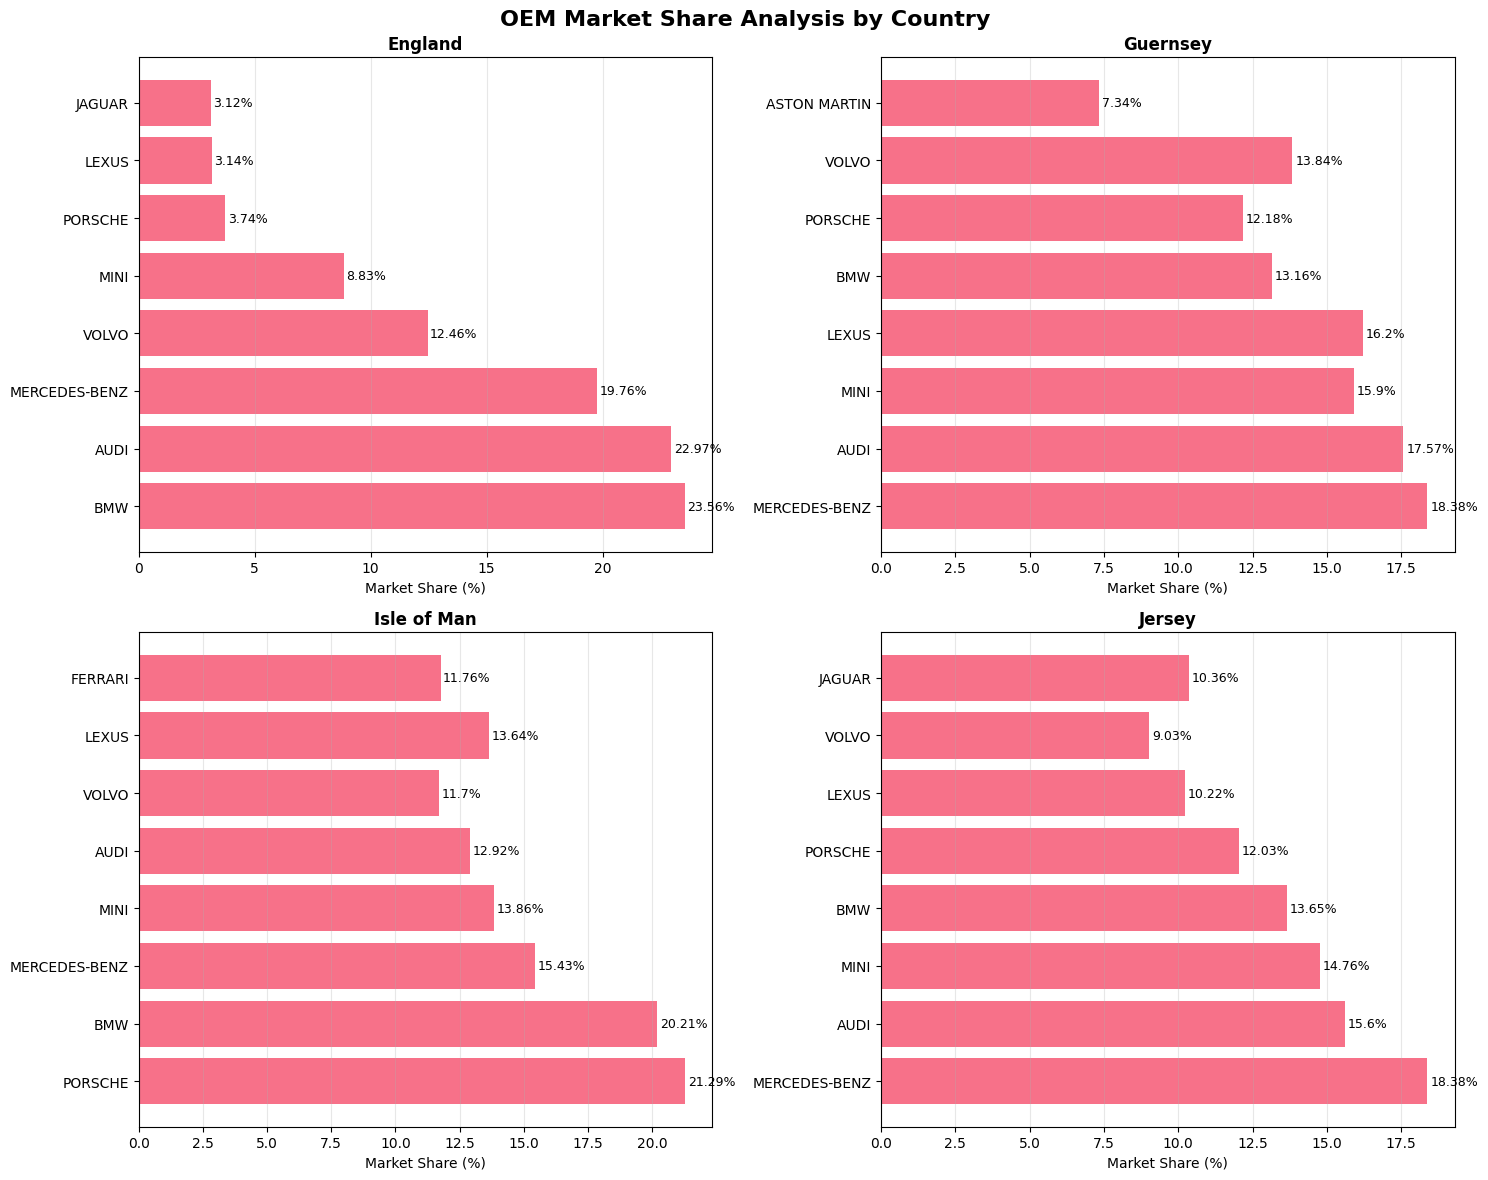

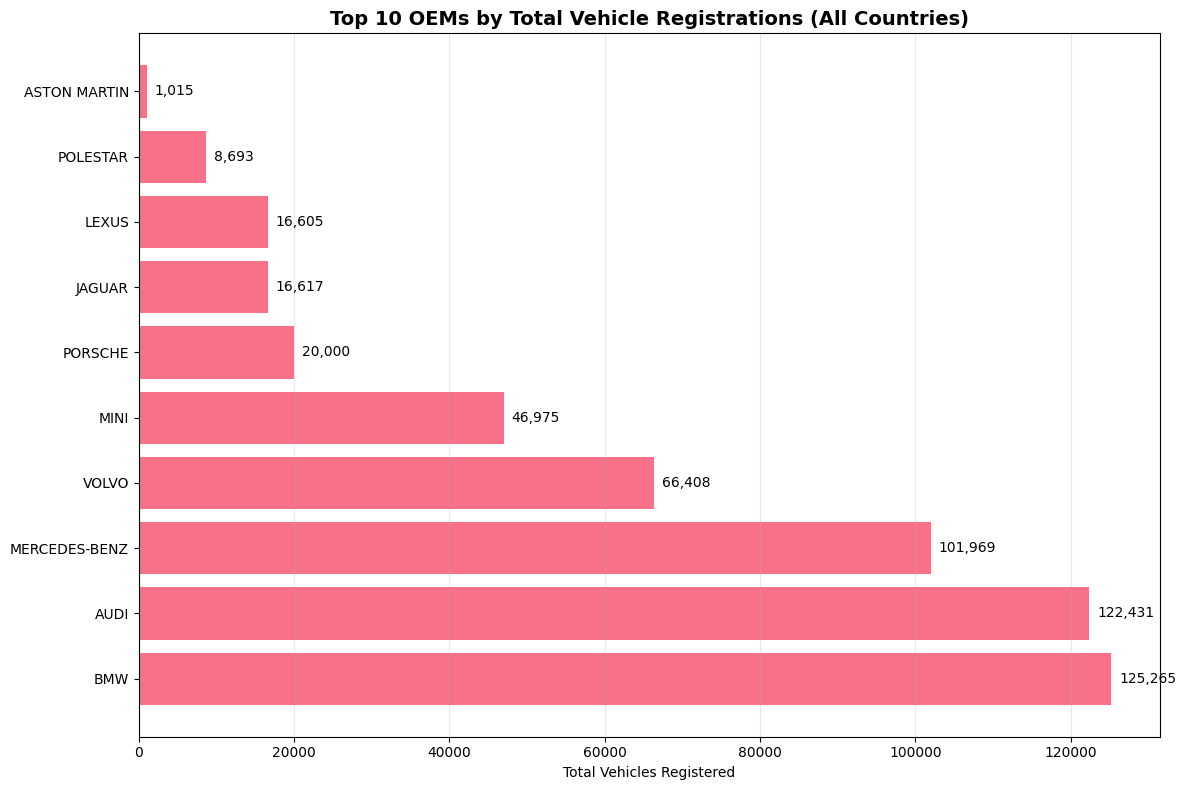

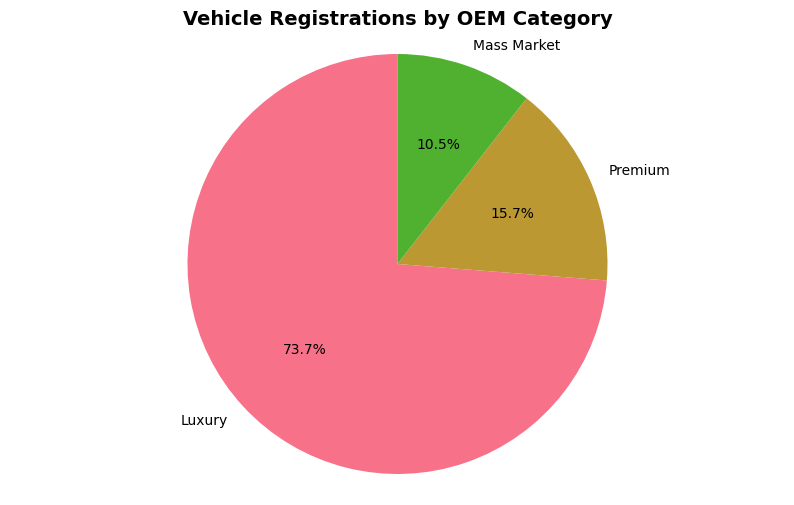

📊 SUMMARY STATISTICS:
Total Countries Analyzed: 8
Total OEMs: 13
Total Vehicle Registrations: 528,306
Average Market Share per OEM-Country: 9.99%


In [127]:
# Create visualizations of the market share data
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
plt.style.use('default')
sns.set_palette("husl")

# 1. Market Share by Country - Top 5 OEMs per country
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('OEM Market Share Analysis by Country', fontsize=16, fontweight='bold')

countries = df_market_share['country_name'].unique()[:4]  # Top 4 countries

for i, country in enumerate(countries):
    ax = axes[i//2, i%2]
    country_data = df_market_share[df_market_share['country_name'] == country].head(8)
    
    bars = ax.barh(country_data['oem_name'], country_data['market_share_percent'])
    ax.set_title(f'{country}', fontweight='bold')
    ax.set_xlabel('Market Share (%)')
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels on bars
    for j, (bar, value) in enumerate(zip(bars, country_data['market_share_percent'])):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                f'{value}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 2. Overall Top 10 OEMs across all countries
plt.figure(figsize=(12, 8))
overall_data = df_market_share.groupby(['oem_name', 'oem_category']).agg({
    'total_vehicles': 'sum',
    'market_share_percent': 'mean'
}).reset_index().sort_values('total_vehicles', ascending=False).head(10)

bars = plt.barh(overall_data['oem_name'], overall_data['total_vehicles'])
plt.title('Top 10 OEMs by Total Vehicle Registrations (All Countries)', fontweight='bold', fontsize=14)
plt.xlabel('Total Vehicles Registered')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for bar, value in zip(bars, overall_data['total_vehicles']):
    plt.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2, 
             f'{value:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# 3. Market Share Distribution by OEM Category
plt.figure(figsize=(10, 6))
category_data = df_market_share.groupby('oem_category').agg({
    'total_vehicles': 'sum',
    'market_share_percent': 'mean'
}).reset_index().sort_values('total_vehicles', ascending=False)

plt.pie(category_data['total_vehicles'], labels=category_data['oem_category'], autopct='%1.1f%%', startangle=90)
plt.title('Vehicle Registrations by OEM Category', fontweight='bold', fontsize=14)
plt.axis('equal')
plt.show()

print("📊 SUMMARY STATISTICS:")
print(f"Total Countries Analyzed: {df_market_share['country_name'].nunique()}")
print(f"Total OEMs: {df_market_share['oem_name'].nunique()}")
print(f"Total Vehicle Registrations: {df_market_share['total_vehicles'].sum():,}")
print(f"Average Market Share per OEM-Country: {df_market_share['market_share_percent'].mean():.2f}%")

In [128]:
# Advanced analytical queries showcasing traditional star schema capabilities
conn = sqlite3.connect("../registered_vehicles.sqlite")

print("🔍 ADVANCED STAR SCHEMA ANALYTICS")
print("=" * 50)

# Query 1: Time series analysis with moving averages
print("\n1. Monthly Registration Trends with 3-Month Moving Average:")
print("-" * 55)

time_series_query = """
SELECT 
    t.year_report,
    t.month_report,
    o.oem_name,
    SUM(f.vehicle_count) as monthly_registrations,
    AVG(SUM(f.vehicle_count)) OVER (
        PARTITION BY o.oem_name 
        ORDER BY t.year_report, t.month_report 
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) as three_month_avg
FROM FactRegisteredVehicles f
JOIN DimTime t ON f.time_key = t.time_key
JOIN DimOEM o ON f.oem_key = o.oem_key
WHERE o.oem_name IN ('BMW', 'AUDI', 'MERCEDES-BENZ')
GROUP BY t.year_report, t.month_report, o.oem_name
ORDER BY o.oem_name, t.year_report, t.month_report;
"""

df_time_series = pd.read_sql_query(time_series_query, conn)

for oem in ['BMW', 'AUDI', 'MERCEDES-BENZ']:
    oem_data = df_time_series[df_time_series['oem_name'] == oem].head(6)
    print(f"\n{oem}:")
    for _, row in oem_data.iterrows():
        print(f"  {row['year_report']}-{row['month_report']:02d}: {row['monthly_registrations']:,} vehicles "
              f"(3-month avg: {row['three_month_avg']:,.0f})")

# Query 2: Cross-dimensional analysis
print("\n\n2. Vehicle Type Performance by Geographic Region:")
print("-" * 50)

cross_dim_query = """
SELECT 
    v.body_type,
    v.fuel_type,
    gc.country_name,
    COUNT(DISTINCT f.oem_key) as num_oems,
    SUM(f.vehicle_count) as total_vehicles,
    AVG(f.vehicle_count) as avg_registration_size
FROM FactRegisteredVehicles f
JOIN DimVehicle v ON f.vehicle_key = v.vehicle_key
JOIN DimGeographyCountry gc ON f.geography_country_key = gc.geography_country_key
WHERE v.body_type IN ('SUV', 'SEDAN', 'ESTATE') 
    AND v.fuel_type IN ('ELECTRIC', 'PETROL')
    AND gc.country_name IN ('England', 'Scotland', 'Wales')
GROUP BY v.body_type, v.fuel_type, gc.country_name
HAVING SUM(f.vehicle_count) > 1000
ORDER BY gc.country_name, total_vehicles DESC;
"""

df_cross_dim = pd.read_sql_query(cross_dim_query, conn)

current_country = None
for _, row in df_cross_dim.iterrows():
    if row['country_name'] != current_country:
        current_country = row['country_name']
        print(f"\n{current_country}:")
    print(f"  {row['body_type']} {row['fuel_type']}: {row['total_vehicles']:,} vehicles "
          f"({row['num_oems']} OEMs, avg: {row['avg_registration_size']:.0f})")

# Query 3: Hierarchical time analysis
print("\n\n3. Quarterly Performance Analysis:")
print("-" * 35)

quarterly_query = """
SELECT 
    t.year_report,
    t.quarter,
    o.oem_category,
    COUNT(DISTINCT o.oem_name) as num_oems,
    SUM(f.vehicle_count) as quarterly_vehicles,
    ROUND(AVG(f.vehicle_count), 2) as avg_transaction_size
FROM FactRegisteredVehicles f
JOIN DimTime t ON f.time_key = t.time_key
JOIN DimOEM o ON f.oem_key = o.oem_key
WHERE t.year_report = 2024
GROUP BY t.year_report, t.quarter, o.oem_category
ORDER BY t.quarter, quarterly_vehicles DESC;
"""

df_quarterly = pd.read_sql_query(quarterly_query, conn)

current_quarter = None
for _, row in df_quarterly.iterrows():
    quarter_label = f"Q{row['quarter']} {row['year_report']}"
    if row['quarter'] != current_quarter:
        current_quarter = row['quarter']
        print(f"\n{quarter_label}:")
    print(f"  {row['oem_category']}: {row['quarterly_vehicles']:,} vehicles "
          f"({row['num_oems']} OEMs)")

conn.close()

print("\n" + "=" * 50)
print("✅ Traditional Star Schema Benefits Demonstrated:")
print("   • Rich multi-dimensional analysis capabilities")
print("   • Efficient joins with proper indexing")
print("   • Temporal hierarchies and window functions")
print("   • Cross-dimensional insights")
print("   • Normalized data consistency")

🔍 ADVANCED STAR SCHEMA ANALYTICS

1. Monthly Registration Trends with 3-Month Moving Average:
-------------------------------------------------------

BMW:
  2024-01: 10,795 vehicles (3-month avg: 10,795)
  2024-02: 5,911 vehicles (3-month avg: 8,353)
  2024-03: 20,065 vehicles (3-month avg: 12,257)
  2024-04: 9,156 vehicles (3-month avg: 11,711)
  2024-05: 10,353 vehicles (3-month avg: 13,191)
  2024-06: 13,547 vehicles (3-month avg: 11,019)

AUDI:
  2024-01: 8,832 vehicles (3-month avg: 8,832)
  2024-02: 5,176 vehicles (3-month avg: 7,004)
  2024-03: 18,454 vehicles (3-month avg: 10,821)
  2024-04: 10,253 vehicles (3-month avg: 11,294)
  2024-05: 10,673 vehicles (3-month avg: 13,127)
  2024-06: 11,929 vehicles (3-month avg: 10,952)

MERCEDES-BENZ:
  2024-01: 5,436 vehicles (3-month avg: 5,436)
  2024-02: 3,225 vehicles (3-month avg: 4,330)
  2024-03: 19,586 vehicles (3-month avg: 9,416)
  2024-04: 6,463 vehicles (3-month avg: 9,758)
  2024-05: 7,641 vehicles (3-month avg: 11,230)
  2